In [1]:
import os
import pandas as pd

# Paths - adjust if needed
LINKED_CSV = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\linked_brain_ehr.csv"
IMG_DIR = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\images_processed"

# Load linked table
df = pd.read_csv(LINKED_CSV)

# Summary checks
print("Total linked records:", len(df))
print("Unique images referenced:", df['image_path'].nunique())
print("Unique diagnoses:", df['diagnosis'].unique())

# Check files exist
missing_images = df[~df['image_path'].apply(os.path.exists)]
print("Missing image file rows:", len(missing_images))
if len(missing_images) > 0:
    print(missing_images[['file_id','image_path']].head())

# Required metadata fields - check presence and non-empty
required_cols = ['file_id','image_path','patient_id','diagnosis','icd10_code']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise SystemExit(f"ERROR: required columns missing from linked CSV: {missing_cols}")

empty_counts = {c: int((df[c].astype(str).str.strip()=='').sum()) for c in required_cols}
print("Empty metadata fields counts:", empty_counts)

# Quick count by modality note (if you maintain modality column)
if 'modality' in df.columns:
    print("Modalities present:", df['modality'].value_counts().to_dict())
else:
    print("No explicit 'modality' column found — by convention all images are MRI for this project.")

# Quick sample of entries for manual inspection
print("\nSample rows:")
display(df[required_cols + ['age','gender']].head(8))


Total linked records: 900
Unique images referenced: 60
Unique diagnoses: ['glioma' 'meningioma' 'notumor' 'pituitary']
Missing image file rows: 0
Empty metadata fields counts: {'file_id': 0, 'image_path': 0, 'patient_id': 0, 'diagnosis': 0, 'icd10_code': 0}
No explicit 'modality' column found — by convention all images are MRI for this project.

Sample rows:


,file_id,image_path,patient_id,diagnosis,icd10_code,age,gender
0,1,C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_...,605fd47e-11bd-4fd6-81af-c714180aea18,glioma,C71.9,61,male
1,2,C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_...,192d72da-9bb8-496d-b76e-05f5c12cdf23,glioma,C71.9,45,male
2,3,C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_...,ba78ce19-f17a-4275-a8c6-0b274f01f22f,glioma,C71.9,47,female
3,4,C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_...,9c015472-10f4-47be-9f0a-2cc9695d4370,glioma,C71.9,70,female
4,5,C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_...,76e26a85-d0d2-4ead-9a37-42197619510e,glioma,C71.9,23,female
5,6,C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_...,b75229b2-504c-44f7-b0ce-d683611d3a1e,glioma,C71.9,38,female
6,7,C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_...,d4e47e20-aff6-411a-8d0d-1a887d5963ad,glioma,C71.9,66,female
7,8,C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_...,15e916dd-4c1d-4980-b686-3d1a1f5e289c,glioma,C71.9,68,male


In [2]:
import os

os.makedirs("data/images_processed", exist_ok=True)
os.makedirs("data/images_enhanced", exist_ok=True)


In [4]:
! "C:\Users\vigne\Downloads\realesrgan-ncnn-vulkan-20220424-windows\realesrgan-ncnn-vulkan.exe" -h


Usage: realesrgan-ncnn-vulkan -i infile -o outfile [options]...

  -h                   show this help
  -i input-path        input image path (jpg/png/webp) or directory
  -o output-path       output image path (jpg/png/webp) or directory
  -s scale             upscale ratio (can be 2, 3, 4. default=4)
  -t tile-size         tile size (>=32/0=auto, default=0) can be 0,0,0 for multi-gpu
  -m model-path        folder path to the pre-trained models. default=models
  -n model-name        model name (default=realesr-animevideov3, can be realesr-animevideov3 | realesrgan-x4plus | realesrgan-x4plus-anime | realesrnet-x4plus)
  -g gpu-id            gpu device to use (default=auto) can be 0,1,2 for multi-gpu
  -j load:proc:save    thread count for load/proc/save (default=1:2:2) can be 1:2,2,2:2 for multi-gpu
  -x                   enable tta mode
  -f format            output image format (jpg/png/webp, default=ext/png)
  -v                   verbose output


In [5]:
! "C:\Users\vigne\Downloads\realesrgan-ncnn-vulkan-20220424-windows\realesrgan-ncnn-vulkan.exe" ^ -i "C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\images_processed" ^ -o "C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\images_enhanced" ^ -n realesrgan-x4plus -s 4


[0 Intel(R) Iris(R) Xe Graphics]  queueC=0[1]  queueG=0[1]  queueT=0[1]
[0 Intel(R) Iris(R) Xe Graphics]  bugsbn1=0  bugbilz=0  bugcopc=0  bugihfa=0
[0 Intel(R) Iris(R) Xe Graphics]  fp16-p/s/a=1/1/1  int8-p/s/a=1/1/1
[0 Intel(R) Iris(R) Xe Graphics]  subgroup=32  basic=1  vote=1  ballot=1  shuffle=1
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.00%
0.00%
25.00%
50.00%
75.

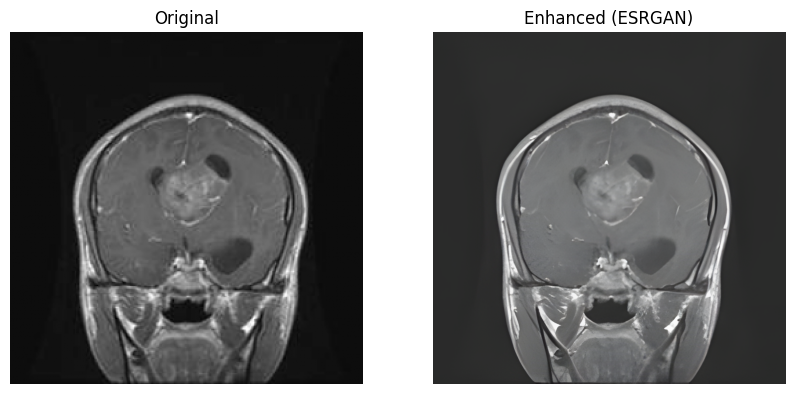

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

orig_path = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\images_processed\glioma_G_1.png"
enh_path  = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\images_enhanced\glioma_G_1.png"

orig = Image.open(orig_path)
enh  = Image.open(enh_path)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(orig, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Enhanced (ESRGAN)")
plt.imshow(enh, cmap='gray')
plt.axis("off")
plt.show()


In [10]:
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
from PIL import Image
import numpy as np
import os

orig_dir = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\images_processed"
enh_dir  = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\images_enhanced"

psnr_scores, ssim_scores = [], []

for fn in os.listdir(orig_dir)[:10]:
    orig_path = os.path.join(orig_dir, fn)
    enh_path = os.path.join(enh_dir, fn)
    
    if os.path.exists(enh_path):
        orig_img = Image.open(orig_path).convert('L')
        enh_img  = Image.open(enh_path).convert('L')
        
        enh_img_resized = enh_img.resize(orig_img.size)
        
        orig = np.array(orig_img)
        enh  = np.array(enh_img_resized)
        
        psnr_val = psnr(orig, enh)
        ssim_val = ssim(orig, enh)
        
        psnr_scores.append(psnr_val)
        ssim_scores.append(ssim_val)
        
        print(f"{fn}: PSNR = {psnr_val:.2f}, SSIM = {ssim_val:.3f}")
    else:
        print(f" Enhanced file not found for: {fn}")

if psnr_scores:
    print("\n Average PSNR:", np.mean(psnr_scores))
    print(" Average SSIM:", np.mean(ssim_scores))
else:
    print("\n No valid image pairs found.")


glioma_G_1.png: PSNR = 34.41, SSIM = 0.971
glioma_G_10.png: PSNR = 26.89, SSIM = 0.867
glioma_G_11.png: PSNR = 27.94, SSIM = 0.929
glioma_G_12.png: PSNR = 35.15, SSIM = 0.973
glioma_G_13.png: PSNR = 32.32, SSIM = 0.956
glioma_G_14.png: PSNR = 34.09, SSIM = 0.875
glioma_G_15.png: PSNR = 33.91, SSIM = 0.895
glioma_G_2.png: PSNR = 32.79, SSIM = 0.958
glioma_G_3.png: PSNR = 33.47, SSIM = 0.864
glioma_G_4.png: PSNR = 33.84, SSIM = 0.888

 Average PSNR: 32.480315608827844
 Average SSIM: 0.9175122964126583


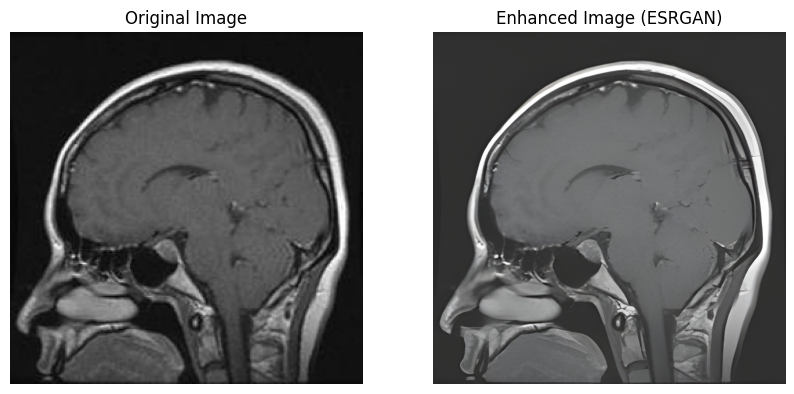

In [13]:
import matplotlib.pyplot as plt
from PIL import Image
import os


orig_dir = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\images_processed"
enh_dir  = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\images_enhanced"


img_name = "pituitary_P_15.png"  


orig_path = os.path.join(orig_dir, img_name)
enh_path  = os.path.join(enh_dir, img_name)  

orig = Image.open(orig_path)
enh  = Image.open(enh_path)


plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(orig, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Enhanced Image (ESRGAN)")
plt.imshow(enh, cmap='gray')
plt.axis('off')

plt.show()



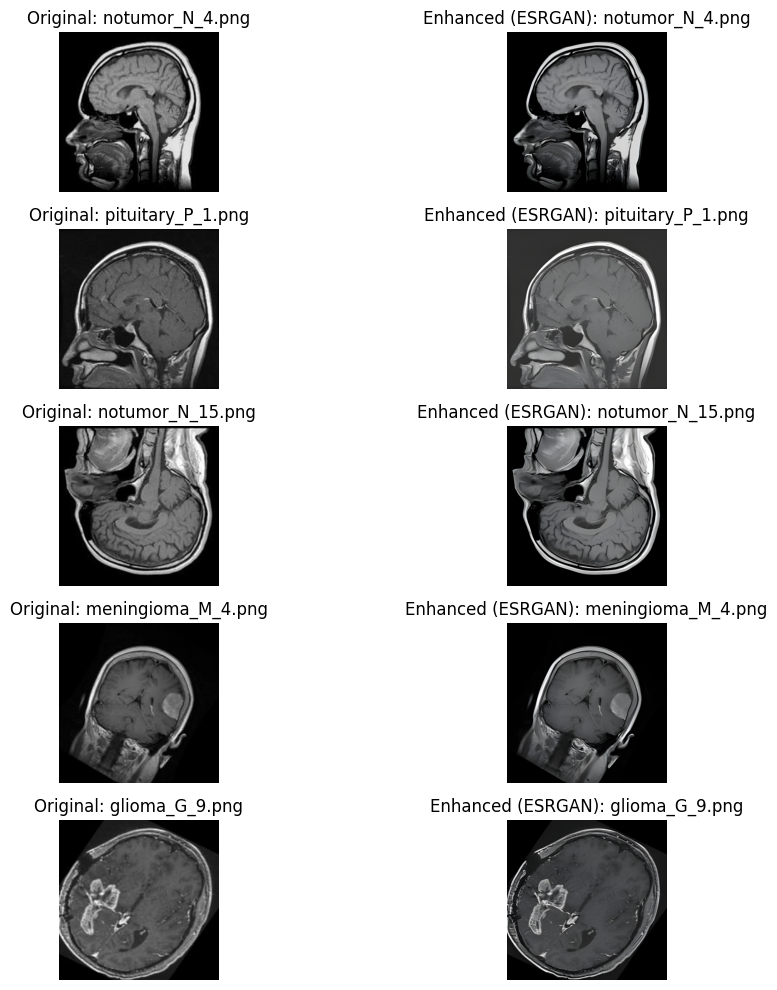

In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import os, random


orig_dir = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\images_processed"
enh_dir  = r"C:\Users\vigne\OneDrive\Desktop\EHR\Enhancing_EHRs_with_GenAI\data\images_enhanced"


images = random.sample(os.listdir(orig_dir), 5)

plt.figure(figsize=(12, 10))

for i, img_name in enumerate(images):
    orig_path = os.path.join(orig_dir, img_name)
    enh_path  = os.path.join(enh_dir, img_name)  

    if os.path.exists(enh_path):
        orig = Image.open(orig_path)
        enh  = Image.open(enh_path)

       
        plt.subplot(5, 2, 2*i + 1)
        plt.imshow(orig, cmap='gray')
        plt.title(f"Original: {img_name}")
        plt.axis('off')

        
        plt.subplot(5, 2, 2*i + 2)
        plt.imshow(enh, cmap='gray')
        plt.title(f"Enhanced (ESRGAN): {img_name}")
        plt.axis('off')

plt.tight_layout()
plt.show()
